In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cmocean as cm
from matplotlib import colors
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')
from dask.distributed import Client
import dask
import os
from azimodecomp import AZIMUTHAL_MODES_fast_v2
client =Client()

import scipy.interpolate as spint
import scipy.spatial.qhull as qhull
import numpy as np

def interp_weights(xy, uv,d=2):
    tri = qhull.Delaunay(xy)
    simplex = tri.find_simplex(uv)
    vertices = np.take(tri.simplices, simplex, axis=0)
    temp = np.take(tri.transform, simplex, axis=0)
    delta = uv - temp[:, d]
    bary = np.einsum('njk,nk->nj', temp[:, :d, :], delta)
    return vertices, np.hstack((bary, 1 - bary.sum(axis=1, keepdims=True)))

def interpolate(values, vtx, wts):
    return np.einsum('nj,nj->n', np.take(values, vtx), wts)

## Routine to decompose the velocity into an azimuthhal and a radial component
def extract_u_proj_azim(x,y,U_take,V_take):
    #this version takes lon and lat wrt the center
    Unorm_take=np.sqrt(U_take**2+V_take**2)
    # now do the projection on the tilted axis between the float and the center oof the eddy
    alph=np.arctan2(y,x)
    beta=np.arctan2(V_take,U_take)
    gam=beta-alph
    #compute componant on tilted axis
    Ur=Unorm_take*np.cos(gam)
    Utheta=Unorm_take*np.sin(gam)
    #print("U theta=",Utheta)
    #print("U r=",Ur)
    return Ur,Utheta


def do_interp_weights_calc(X,Y,Xi,Yi):           #####beware, it takes y and x !!!!
    xy=np.zeros([X.shape[0]*X.shape[1],2])
    xy[:,0]=Y.flatten()
    xy[:,1]=X.flatten()
    uv=np.zeros([Xi.shape[0]*Xi.shape[1],2])
    uv[:,0]=Yi.flatten()
    uv[:,1]=Xi.flatten()
    vtx, wts = interp_weights(xy, uv)
    return vtx,wts


def coriolis_frequency(latitude_degrees):
    import math
    omega = 7.2921e-5  # Earth's angular velocity (rad/s)
    phi_rad = math.radians(latitude_degrees)
    f0 = 2 * omega * math.sin(phi_rad)
    return f0

lat=80
f0=coriolis_frequency(lat);print(f0)
path_root='/home/datawork-lops-osi/cdemarez/5_SECTION19/ICE-EDDY_wJ/V4/'

In [ ]:
#parameters to compute the modal decomposition
#dimension of the r,theta grid
nr=100 #number of radial points to interpole on the r,theta grid
nth=360 #number of azimuthal points

#the modes chosen for the decomposition
modes=np.arange(0,20,1)

#the level for computation
ilev=-1

#the times for computation
itimes=np.arange(7,90,1)



def get_modal(data):

    #center the grid
    x=np.copy(X[:,:,-1])
    y=np.copy(Y[:,:,-1])

    x=0.25*(x[1:,1:]+x[1:,:-1]+x[:-1,1:]+x[:-1,:-1])
    y=0.25*(y[1:,1:]+y[1:,:-1]+y[:-1,1:]+y[:-1,:-1])

    dx=np.diff(x,axis=1)[0,0]*1e3 #dx in m
    dy=dx
    print(dx)

    ###first compute the weights and coef for the interpolation on the r,theta grid

    #create the (r,theta) grid
    rmax=100 #in km 
    r=np.linspace(0,rmax,nr)
    theta=np.linspace(0,2*np.pi,nth)
    dth=np.diff(theta)[0]
    r,theta=np.meshgrid(r,theta)
    r=r.T
    theta=theta.T
    x_polar=r*np.cos(theta)
    y_polar=r*np.sin(theta)
    r_x=np.sqrt(x**2+y**2)
    print('Compute the weights for interpolation from (x,y) to (r,theta) grids')
    vtx_x_to_r, wts_x_to_r=do_interp_weights_calc(y,x,y_polar,x_polar)
    print('Compute the weights for interpolation from (r,theta) to (x,y) grids')
    vtx_r_to_x, wts_r_to_x=do_interp_weights_calc(y_polar,x_polar,y,x)





    modal_decomp_vort_all=[]
    Sum_Ek_modes_ilev_all=[]


    U_init = data.U.isel(time=itimes[0]).transpose("yC","xF","zC")[:,:,ilev].to_numpy()
    V_init = data.V.isel(time=itimes[0]).transpose("yF","xC","zC")[:,:,ilev].to_numpy()
    U_init=0.5*(U_init[:,1:]+U_init[:,:-1])
    V_init=0.5*(V_init[1:,:]+V_init[:-1,:])


    for itime in itimes:

        print(itime)
        U_tmp = data.U.isel(time=itime).transpose("yC","xF","zC")[:,:,ilev].to_numpy()
        V_tmp = data.V.isel(time=itime).transpose("yF","xC","zC")[:,:,ilev].to_numpy()
        U_tmp=0.5*(U_tmp[:,1:]+U_tmp[:,:-1])
        V_tmp=0.5*(V_tmp[1:,:]+V_tmp[:-1,:])
        vort_tmp = data.vort.isel(time=itime).transpose("yF","xF","zC")[:,:,ilev].to_numpy()
        vort_tmp=0.25*(vort_tmp[1:,1:]+vort_tmp[1:,:-1]+vort_tmp[:-1,1:]+vort_tmp[:-1,:-1])

        u_perturb=U_tmp-U_init
        v_perturb=V_tmp-V_init
        ur_perturb,utheta_perturb=extract_u_proj_azim(x,y,u_perturb,v_perturb)
        VAR1=utheta_perturb
        VAR2=ur_perturb
        VAR3=vort_tmp

        #compute the modal decomposition
        art1,ampl1,phaz1,psi1,psi_xy1=AZIMUTHAL_MODES_fast_v2(x,y,r_x,rmax,x_polar,y_polar,r,theta,nr,nth,dth,\
                                                 vtx_x_to_r,wts_x_to_r,\
                                                 vtx_r_to_x, wts_r_to_x,\
                                                 VAR1,modes)
        art2,ampl2,phaz2,psi2,psi_xy2=AZIMUTHAL_MODES_fast_v2(x,y,r_x,rmax,x_polar,y_polar,r,theta,nr,nth,dth,\
                                                 vtx_x_to_r,wts_x_to_r,\
                                                 vtx_r_to_x, wts_r_to_x,\
                                                 VAR2,modes)

        art3,ampl3,phaz3,psi3,psi_xy3=AZIMUTHAL_MODES_fast_v2(x,y,r_x,rmax,x_polar,y_polar,r,theta,nr,nth,dth,\
                                                 vtx_x_to_r,wts_x_to_r,\
                                                 vtx_r_to_x, wts_r_to_x,\
                                                 VAR3,modes)

        Ek_itime_modes_ilev=0.5*(psi_xy1**2+psi_xy2**2)
        Ek_itime_ilev=0.5*(VAR1**2+VAR2**2) 

        Sum_Ek_itime_modes_ilev=np.nansum(Ek_itime_modes_ilev*dx*dx,axis=(1,2))


        modal_decomp_vort_all.append(psi_xy3)
        Sum_Ek_modes_ilev_all.append(Sum_Ek_itime_modes_ilev)

    modal_decomp_vort_all=np.array(modal_decomp_vort_all)
    Sum_Ek_modes_ilev_all=np.array(Sum_Ek_modes_ilev_all).T
    
    
    return Sum_Ek_modes_ilev_all, modal_decomp_vort_all

In [ ]:
Sum_Ek_modes_ilev_all,modal_decomp_vort_all={},{}

In [ ]:
experiment="A-H3-H-LR/"




data_path = path_root+"/RUN/"+experiment



vel_fields = "vel_fields*.nc"
tracer_fields = "tracer_fields*.nc"
vel_fields_paths = '{0}/{1}'.format(data_path, vel_fields)
tracer_fields_paths = '{0}/{1}'.format(data_path, tracer_fields)

data = xr.open_mfdataset(vel_fields_paths)# preprocess=remove_empty_ds )

var = data.vort.isel(time=15).transpose("yF","xF","zC")

Ny, Nx, Nz = var.shape

X = np.ones((Ny,Nx,Nz)) * var.xF.values[np.newaxis,:,np.newaxis] / 1000
Y = np.ones((Ny,Nx,Nz)) * var.yF.values[:, np.newaxis,np.newaxis] / 1000
Z = np.ones((Ny,Nx,Nz)) * var.zC.values[np.newaxis,np.newaxis,:]
ax=plt.subplot(111,aspect='equal')
plt.pcolormesh(X[:,:,iz],Y[:,:,iz],var[:,:,iz]/f0,cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
Sum_Ek_modes_ilev_all[experiment], modal_decomp_vort_all[experiment]=get_modal(data)





In [ ]:

ax=plt.subplot(111)
for imode in range(1,5,1):
    plt.plot(itimes,Sum_Ek_modes_ilev_all[experiment][imode],
            label=str(imode))
    plt.legend()
#ax.set_ylim(0,10)
plt.show()

In [ ]:
imode=1
i=2
itime=itimes[i]

plt.title('u_theta mode 2 at this level')
plt.pcolormesh(modal_decomp_vort_all[experiment][i,imode]/f0,cmap='jet')
plt.colorbar()
plt.show()

# compare different simulations

In [ ]:
experiments=["A-H1-nonoise-H-LR",
             "A-H2-nonoise-H-LR",
             "A-H21-nonoise-H-LR",
             "A-H3-nonoise-H-LR",
             "A-H4-nonoise-H-LR",
             "A-H1-H-LR",
             "A-H2-H-LR",
             "A-H21-H-LR",
             "A-H3-H-LR",
             "A-H4-H-LR"]

experiments=["A-H1-H-LR",
             "A-H2-H-LR",
             "A-H21-H-LR",
             "A-H3-H-LR",
             "A-H4-H-LR",
             "A-H5-H-LR"]

"""experiments=["A-H1-L-LR",
             "A-H2-L-LR",
             "A-H21-H-LR",
             "A-H3-L-LR",
             "A-H5-L-LR"]"""

Sum_Ek_modes_ilev_all,modal_decomp_vort_all={},{}


for experiment in experiments:

    data_path = path_root+"/RUN/"+experiment

    print(experiment)


    vel_fields = "vel_fields*.nc"
    tracer_fields = "tracer_fields*.nc"
    vel_fields_paths = '{0}/{1}'.format(data_path, vel_fields)
    tracer_fields_paths = '{0}/{1}'.format(data_path, tracer_fields)

    data = xr.open_mfdataset(vel_fields_paths)# preprocess=remove_empty_ds )

    var = data.vort.isel(time=15).transpose("yF","xF","zC")

    Ny, Nx, Nz = var.shape

    X = np.ones((Ny,Nx,Nz)) * var.xF.values[np.newaxis,:,np.newaxis] / 1000
    Y = np.ones((Ny,Nx,Nz)) * var.yF.values[:, np.newaxis,np.newaxis] / 1000
    Z = np.ones((Ny,Nx,Nz)) * var.zC.values[np.newaxis,np.newaxis,:]



    Sum_Ek_modes_ilev_all[experiment], modal_decomp_vort_all[experiment]=get_modal(data)


A-H1-H-LR
4000.0
Compute the weights for interpolation from (x,y) to (r,theta) grids


getfattr: /home/datawork-lops-osi/cdemarez/5_SECTION19/ICE-EDDY_wJ/V4/RUN/A-H1-H-LR/vel_fields.nc: Operation not supported


Compute the weights for interpolation from (r,theta) to (x,y) grids


getfattr: /home/datawork-lops-osi/cdemarez/5_SECTION19/ICE-EDDY_wJ/V4/RUN/A-H1-H-LR/vel_fields.nc: Operation not supported


7
8


...

getfattr: /home/datawork-lops-osi/cdemarez/5_SECTION19/ICE-EDDY_wJ/V4/RUN/A-H4-H-LR/vel_fields.nc: Operation not supported


20


getfattr: /home/datawork-lops-osi/cdemarez/5_SECTION19/ICE-EDDY_wJ/V4/RUN/A-H4-H-LR/vel_fields.nc: Operation not supported


21


getfattr: /home/datawork-lops-osi/cdemarez/5_SECTION19/ICE-EDDY_wJ/V4/RUN/A-H4-H-LR/vel_fields.nc: Operation not supported


In [ ]:
'''##AEs-H-LR

Hs=[50,100,150,200,400,
    50,100,150,200,400]

lss=['--','--','--','--','--',
    '-','-','-','-','-']

lws=[0.5,0.5,0.5,0.5,0.5,1,1,1,1,1,]

col_def= plt.rcParams['axes.prop_cycle'].by_key()['color']

cols=np.concatenate([col_def[:5],col_def[:5]])
'''

##AEs-L-LR

Hs=[50,100,150,200,800]

lss=['-','-','-','-','-']

lws=[1,1,1,1,1]

col_def= plt.rcParams['axes.prop_cycle'].by_key()['color']

cols=np.concatenate([col_def[:5],col_def[:5]])

##AEs-H-LR

Hs=[50,100,150,200,400800]

lss=['-','-','-','-','-','-']

lws=[1,1,1,1,1,1]

col_def= plt.rcParams['axes.prop_cycle'].by_key()['color']

cols=np.concatenate([col_def[:6],col_def[:6]])

In [ ]:
experiments

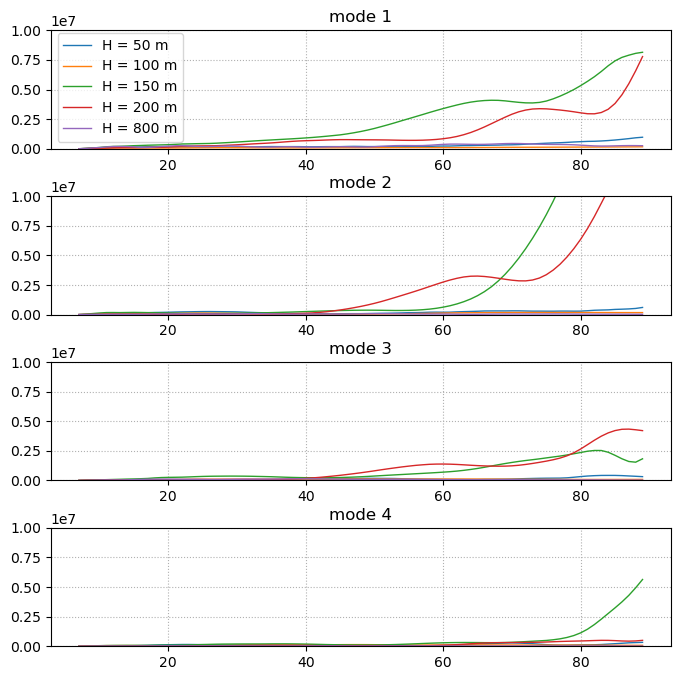

In [32]:
plt.figure(figsize=(8,8))

iplot=1
for imode in [1,2,3,4]:
    ax=plt.subplot(4,1,iplot)
    plt.title('mode {}'.format(imode))
    
    itmp=0
    for experiment in experiments:
        
        if (itmp<6) & (iplot==1):
            lab='H = {} m'.format(Hs[itmp])
            plt.plot(itimes,Sum_Ek_modes_ilev_all[experiment][imode],ls=lss[itmp],c=cols[itmp],lw=lws[itmp],
                    label=lab)
        
        else:
            plt.plot(itimes,Sum_Ek_modes_ilev_all[experiment][imode],ls=lss[itmp],c=cols[itmp],lw=lws[itmp],
                    )
        
        itmp+=1
    
    
    
    if iplot==1: plt.legend()
    
    ##AEs-H-LR
    ax.set_ylim(0,1e8)
    ##AEs-L-LR
    ax.set_ylim(0,1e7)

    
    plt.grid(ls=':')
    iplot+=1
    
plt.subplots_adjust(hspace=0.4)

#plt.savefig('tmp_modal_decomp_AEs-H-LR.png',dpi=300)

plt.show()

In [ ]:

plt.title('u_theta perturbation at this level')
plt.pcolormesh(VAR1,cmap='jet')
plt.colorbar()
plt.show()

plt.title('u_r perturbation at this level')
plt.pcolormesh(VAR2,cmap='jet')
plt.colorbar()
plt.show()

plt.title('KE perturbation at this level')
plt.pcolormesh(Ek_itime_ilev,cmap='hot')
plt.colorbar()
plt.show()

plt.title('u_theta mode 2 at this level')
plt.pcolormesh(psi_xy1[2],cmap='jet')
plt.colorbar()
plt.show()


plt.title('KE mode 2 at this level')
plt.pcolormesh(Ek_itime_modes_ilev[2],cmap='hot')
plt.colorbar()
plt.show()